In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import random

In [47]:
class IntegerDamathGame:
    def __init__(self):
        # 1. Stores the original signed integer value of the piece. Used for calculation.
        self.board_values = np.zeros((8, 8), dtype=int)
        # 2. Stores the owner ID: 1 for Blue (P1), -1 for Red (P2), 0 for empty. Used for move validity.
        self.board_owners = np.zeros((8, 8), dtype=int)
        
        self.operations = [
            ['x', None, '÷', None, '-', None, '+', None],
            [None, '+', None, 'x', None, '+', None, '-'],
            ['-', None, '+', None, 'x', None, '÷', None],
            [None, '+', None, '-', None, '÷', None, 'x'],
            ['x', None, '÷', None, '-', None, '+', None],
            [None, '+', None, 'x', None, '+', None, '-'],
            ['-', None, '+', None, 'x', None, '÷', None],
            [None, '+', None, '-', None, '÷', None, 'x']
        ]
        self.setup_board()
        self.current_player = 1  # 1 for blue, -1 for red
        self.score_p1 = 0
        self.score_p2 = 0
            
    def setup_board(self):
        # Piece values (signed integers) as per the game board image
        initial_board_values = np.zeros((8, 8), dtype=int)
        
        # Blue pieces (Player 1) at top - rows 0, 1, 2
        initial_board_values[0, 2] = 2; initial_board_values[0, 4] = -5; initial_board_values[0, 6] = 8; initial_board_values[0, 0] = -11 
        initial_board_values[1, 1] = -7; initial_board_values[1, 3] = 10; initial_board_values[1, 5] = -3; initial_board_values[1, 7] = 0
        initial_board_values[2, 2] = 4; initial_board_values[2, 4] = -1; initial_board_values[2, 6] = 9; initial_board_values[2, 0] = -6
        
        # Red pieces (Player 2) at bottom - rows 5, 6, 7
        initial_board_values[5, 1] = -9; initial_board_values[5, 3] = 6; initial_board_values[5, 5] = -1; initial_board_values[5, 7] = 4
        initial_board_values[6, 0] = 0; initial_board_values[6, 2] = -3; initial_board_values[6, 4] = 10; initial_board_values[6, 6] = -7
        initial_board_values[7, 1] = -11; initial_board_values[7, 3] = 8; initial_board_values[7, 5] = -5; initial_board_values[7, 7] = 2

        # Populate both boards
        for r in range(8):
            for c in range(8):
                val = initial_board_values[r, c]
                if val != 0:
                    self.board_values[r, c] = val
                    if r < 3: # Blue (P1)
                        self.board_owners[r, c] = 1
                    elif r >= 5: # Red (P2)
                        self.board_owners[r, c] = -1
                        
    def print_board_ascii(self, header=True):
        # NEW: No horizontal separator lines at all.
        
        if header:
            print("\n   0     1     2     3     4     5     6     7  ")
            # The space below the header is implicitly handled by the next print.

        for r in range(8):
            row_str = f"{r} "
            for c in range(8):
                val = self.board_values[r, c]
                owner = self.board_owners[r, c]
                op = self.operations[r][c]
                
                # Format the signed integer value for display
                if val > 0:
                    val_str = f"+{val}"
                elif val < 0:
                    val_str = f"{val}"
                else:
                    val_str = " 0"

                if owner == 0:
                    if op is not None:
                        content = f" {op} " 
                    else:
                        content = " . "
                else:
                    sign = 'B' if owner == 1 else 'R' 
                    content = f"{sign}{val_str: >2}" 
                
                # Column separator uses a space
                row_str += f" {content} " 
            row_str += f" {r}" # Right side row number
            print(row_str)
    
    def get_state(self):
        # State includes both boards (values and owners)
        return (self.board_values.tobytes(), self.board_owners.tobytes(), self.score_p1, self.score_p2)

    def apply_operation(self, value1, value2, operation):
        """Apply the mathematical operation using the stored signed integer values."""
        
        v1 = value1 # Moving piece value
        v2 = value2 # Captured piece value (or 0 for a move)
        
        if operation == '+':
            return v1 + v2
        elif operation == '-':
            return v1 - v2
        elif operation == 'x':
            return v1 * v2
        elif operation == '÷':
            # Integer division is standard. Handle division by zero gracefully.
            return v1 // v2 if v2 != 0 else v1 
        
        # Default score for a 'move' to an operation square (a standard Damath rule)
        return v1 if operation in ['+', '-', 'x', '÷'] else 0 


    def get_valid_moves(self, player):
        moves = []
        for row in range(8):
            for col in range(8):
                owner = self.board_owners[row][col]
                if owner == player:
                    
                    directions = [(1, 1), (1, -1)] if player == 1 else [(-1, 1), (-1, -1)]

                    for dr, dc in directions:
                        new_row, new_col = row + dr, col + dc
                        
                        # Regular move to empty square
                        if (0 <= new_row < 8 and 0 <= new_col < 8 and 
                            self.board_owners[new_row][new_col] == 0 and
                            self.operations[new_row][new_col] is not None):
                            moves.append(((row, col), (new_row, new_col), 'move'))
                        
                        # Capture move
                        jump_row, jump_col = row + 2*dr, col + 2*dc
                        mid_row, mid_col = row + dr, col + dc
                        
                        if (0 <= jump_row < 8 and 0 <= jump_col < 8 and
                            0 <= mid_row < 8 and 0 <= mid_col < 8 and
                            self.board_owners[jump_row][jump_col] == 0 and
                            self.operations[jump_row][jump_col] is not None):
                            
                            mid_owner = self.board_owners[mid_row][mid_col]
                            # Check if the piece in the middle is an opponent (owner != 0 and opposite sign)
                            if mid_owner == -player:
                                moves.append(((row, col), (jump_row, jump_col), 'capture'))
        return moves

    def make_move(self, move):
        (from_r, from_c), (to_r, to_c), move_type = move
        
        moving_piece_value = self.board_values[from_r][from_c]
        moving_piece_owner = self.board_owners[from_r][from_c]
        operation = self.operations[to_r][to_c]
        
        captured_piece_value = 0
        
        if move_type == 'capture':
            mid_r = (from_r + to_r) // 2
            mid_c = (from_c + to_c) // 2
            
            captured_piece_value = self.board_values[mid_r][mid_c]
            
            score = self.apply_operation(moving_piece_value, captured_piece_value, operation)
            
            # Remove captured piece
            self.board_values[mid_r][mid_c] = 0
            self.board_owners[mid_r][mid_c] = 0
            
        elif move_type == 'move':
            # Second value is 0 for regular move calculation
            score = self.apply_operation(moving_piece_value, 0, operation) 

        if self.current_player == 1:
            self.score_p1 += score
        else:
            self.score_p2 += score

        # Move the piece: update both boards at destination and clear source
        self.board_values[to_r][to_c] = moving_piece_value
        self.board_owners[to_r][to_c] = moving_piece_owner
        
        self.board_values[from_r][from_c] = 0
        self.board_owners[from_r][from_c] = 0
        
        return score, captured_piece_value # Return captured piece value for printing

    def is_terminal(self):
        p1_moves = len(self.get_valid_moves(1)); p2_moves = len(self.get_valid_moves(-1))
        p1_pieces = np.sum(self.board_owners == 1); p2_pieces = np.sum(self.board_owners == -1)
        return p1_moves == 0 or p2_moves == 0 or p1_pieces == 0 or p2_pieces == 0

    def get_winner(self):
        if self.score_p1 > self.score_p2: return 1
        elif self.score_p2 > self.score_p1: return -1
        return 0

    def get_reward(self, player):
        if self.is_terminal():
            score_diff = self.score_p1 - self.score_p2
            return score_diff if player == 1 else -score_diff
        return 0

    def copy(self):
        new_game = IntegerDamathGame()
        new_game.board_values = self.board_values.copy()
        new_game.board_owners = self.board_owners.copy()
        new_game.current_player = self.current_player
        new_game.score_p1 = self.score_p1
        new_game.score_p2 = self.score_p2
        return new_game

In [48]:
class QLearningAgent:
    def __init__(self, player, alpha=0.15, gamma=0.95, epsilon=0.25):
        self.player = player
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, game, explore=True):
        state = game.get_state()
        valid_moves = game.get_valid_moves(self.player)

        if not valid_moves: return None

        captures = [m for m in valid_moves if m[2] == 'capture']

        if explore and random.random() < self.epsilon:
            if captures and random.random() < 0.7: return random.choice(captures)
            return random.choice(valid_moves)

        best_value = float('-inf')
        best_move = valid_moves[0]

        for move in valid_moves:
            move_key = str(move)
            q_value = self.q_table[state][move_key]
            if q_value > best_value:
                best_value = q_value
                best_move = move
        return best_move

    def update_q_value(self, state, action, reward, next_state, next_valid_moves):
        action_key = str(action)
        current_q = self.q_table[state][action_key]

        max_next_q = 0
        if next_valid_moves:
            max_next_q = max([self.q_table[next_state][str(move)] for move in next_valid_moves], default=0)

        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action_key] = new_q

In [49]:
def train_agents(episodes=1000, print_moves=False):
    agent1 = QLearningAgent(player=1, alpha=0.15, gamma=0.95, epsilon=0.25)
    agent2 = QLearningAgent(player=-1, alpha=0.15, gamma=0.95, epsilon=0.25)

    results = []
    wins_p1 = 0
    wins_p2 = 0
    draws = 0
    total_score_p1 = 0
    total_score_p2 = 0

    for episode in range(episodes):
        game = IntegerDamathGame()
        move_count = 0
        max_moves = 150
        history = [] 
        
        if print_moves and episode == 0:
            print(f"\n--- Episode {episode + 1}: Initial Board State (Pure Signed Values) ---")
            game.print_board_ascii(header=True)
            
        while not game.is_terminal() and move_count < max_moves:
            current_player_id = game.current_player
            current_agent = agent1 if current_player_id == 1 else agent2
            player_name = "Blue (P1)" if current_player_id == 1 else "Red (P2)"
            state = game.get_state()

            action = current_agent.get_action(game)
            if action is None:
                if print_moves and episode == 0:
                    print(f"\n[{player_name}] has no valid moves. Game ends.")
                break

            (from_r, from_c), (to_r, to_c), move_type = action
            
            # make_move returns (score, captured_piece_value)
            immediate_score_gain, captured_piece_value = game.make_move(action)
            immediate_reward = immediate_score_gain * 2

            if print_moves and episode == 0:
                # Value of the piece that just moved is now simply at the destination board_values
                moving_piece_val = game.board_values[to_r][to_c]
                op_symbol = game.operations[to_r][to_c] if game.operations[to_r][to_c] else '?'

                print(f"\n--- Move {move_count + 1} ---")
                
                # --- NEW: Display the Equation ---
                if move_type == 'capture':
                    # captured_piece_value is the pure signed value
                    print(f"[{player_name}] **CAPTURES**. Equation: **{moving_piece_val} {op_symbol} {captured_piece_value} = {immediate_score_gain}**.")
                else:
                    print(f"[{player_name}] **MOVES**. Equation: **{moving_piece_val} {op_symbol} 0 = {immediate_score_gain}**.")
                # ---------------------------------
                
                print(f"    Piece {moving_piece_val} moved from ({from_r}, {from_c}) to ({to_r}, {to_c}).")
                print(f"    Total Score: P1={game.score_p1}, P2={game.score_p2}")
                game.print_board_ascii(header=False)

            history.append({'state': state, 'action': action, 'immediate_reward': immediate_reward, 'agent': current_agent})
            game.current_player *= -1
            move_count += 1
            
        final_reward_p1 = game.get_reward(1) 
        final_reward_p2 = game.get_reward(-1)
        
        for i in range(len(history)):
            move_data = history[i]
            agent = move_data['agent']
            state = move_data['state']
            action = move_data['action']
            reward = move_data['immediate_reward']
            next_state = game.get_state() 
            next_moves = game.get_valid_moves(-agent.player) 
            
            if i == len(history) - 1 and game.is_terminal():
                reward += final_reward_p1 if agent.player == 1 else final_reward_p2
            agent.update_q_value(state, action, reward, next_state, next_moves)
            
        total_score_p1 += game.score_p1 
        total_score_p2 += game.score_p2 

        winner = game.get_winner()
        if winner == 1: wins_p1 += 1
        elif winner == -1: wins_p2 += 1
        else: draws += 1

        if (episode + 1) % 50 == 0:
            avg_score_p1 = total_score_p1 / (episode + 1)
            avg_score_p2 = total_score_p2 / (episode + 1)
            results.append({
                'Episode': episode + 1, 'Blue Wins': wins_p1, 'Red Wins': wins_p2, 'Draws': draws, 
                'Blue Win %': wins_p1 / (episode + 1) * 100, 'Avg Blue Score': avg_score_p1, 'Avg Red Score': avg_score_p2
            })
            
    return agent1, agent2, results

In [50]:
print("="*80)
print("DEMONSTRATION: Running the first training episode with revised piece identifiers.")
print("BXX = Blue Piece (P1), RXX = Red Piece (P2). Value is the original integer.")
print("="*80)

# Run only 1 episode with printing enabled
agent1_demo, agent2_demo, _ = train_agents(episodes=1, print_moves=True)

print("\n\n--- Training 1000 Episodes (Moves suppressed) ---")
# Reset and run the full training without printing moves
agent1, agent2, results = train_agents(episodes=1000)

# Create results table
df = pd.DataFrame(results)
print("\nTRAINING RESULTS TABLE")
print("="*80)
print(df.to_string(index=False))
print("="*80)

DEMONSTRATION: Running the first training episode with revised piece identifiers.
BXX = Blue Piece (P1), RXX = Red Piece (P2). Value is the original integer.

--- Episode 1: Initial Board State (Pure Signed Values) ---

   0     1     2     3     4     5     6     7  
0  B-11   .   B+2   .   B-5   .   B+8   .   0
1   .   B-7   .   B+10   .   B-3   .    -   1
2  B-6   .   B+4   .   B-1   .   B+9   .   2
3   .    +    .    -    .    ÷    .    x   3
4   x    .    ÷    .    -    .    +    .   4
5   .   R-9   .   R+6   .   R-1   .   R+4  5
6   -    .   R-3   .   R+10   .   R-7   .   6
7   .   R-11   .   R+8   .   R-5   .   R+2  7

--- Move 1 ---
[Blue (P1)] **MOVES**. Equation: **-1 - 0 = -1**.
    Piece -1 moved from (2, 4) to (3, 3).
    Total Score: P1=-1, P2=0
0  B-11   .   B+2   .   B-5   .   B+8   .   0
1   .   B-7   .   B+10   .   B-3   .    -   1
2  B-6   .   B+4   .    x    .   B+9   .   2
3   .    +    .   B-1   .    ÷    .    x   3
4   x    .    ÷    .    -    .    +    .   4
5  

In [51]:
df = pd.DataFrame(results)
print("\nTRAINING RESULTS TABLE")
print("="*80)
print(df.to_string(index=False))
print("="*80)


TRAINING RESULTS TABLE
 Episode  Blue Wins  Red Wins  Draws  Blue Win %  Avg Blue Score  Avg Red Score
      50         28        22      0   56.000000      -26.860000     -28.200000
     100         42        58      0   42.000000      -27.740000     -11.890000
     150         63        87      0   42.000000      -31.380000     -15.713333
     200         83       117      0   41.500000      -29.320000     -13.845000
     250        103       147      0   41.200000      -30.204000     -15.644000
     300        119       181      0   39.666667      -29.793333     -14.000000
     350        140       210      0   40.000000      -29.491429     -12.860000
     400        162       238      0   40.500000      -27.162500     -11.412500
     450        182       267      1   40.444444      -26.957778      -8.888889
     500        206       292      2   41.200000      -25.968000      -8.998000
     550        234       314      2   42.545455      -25.330909     -10.350909
     600        

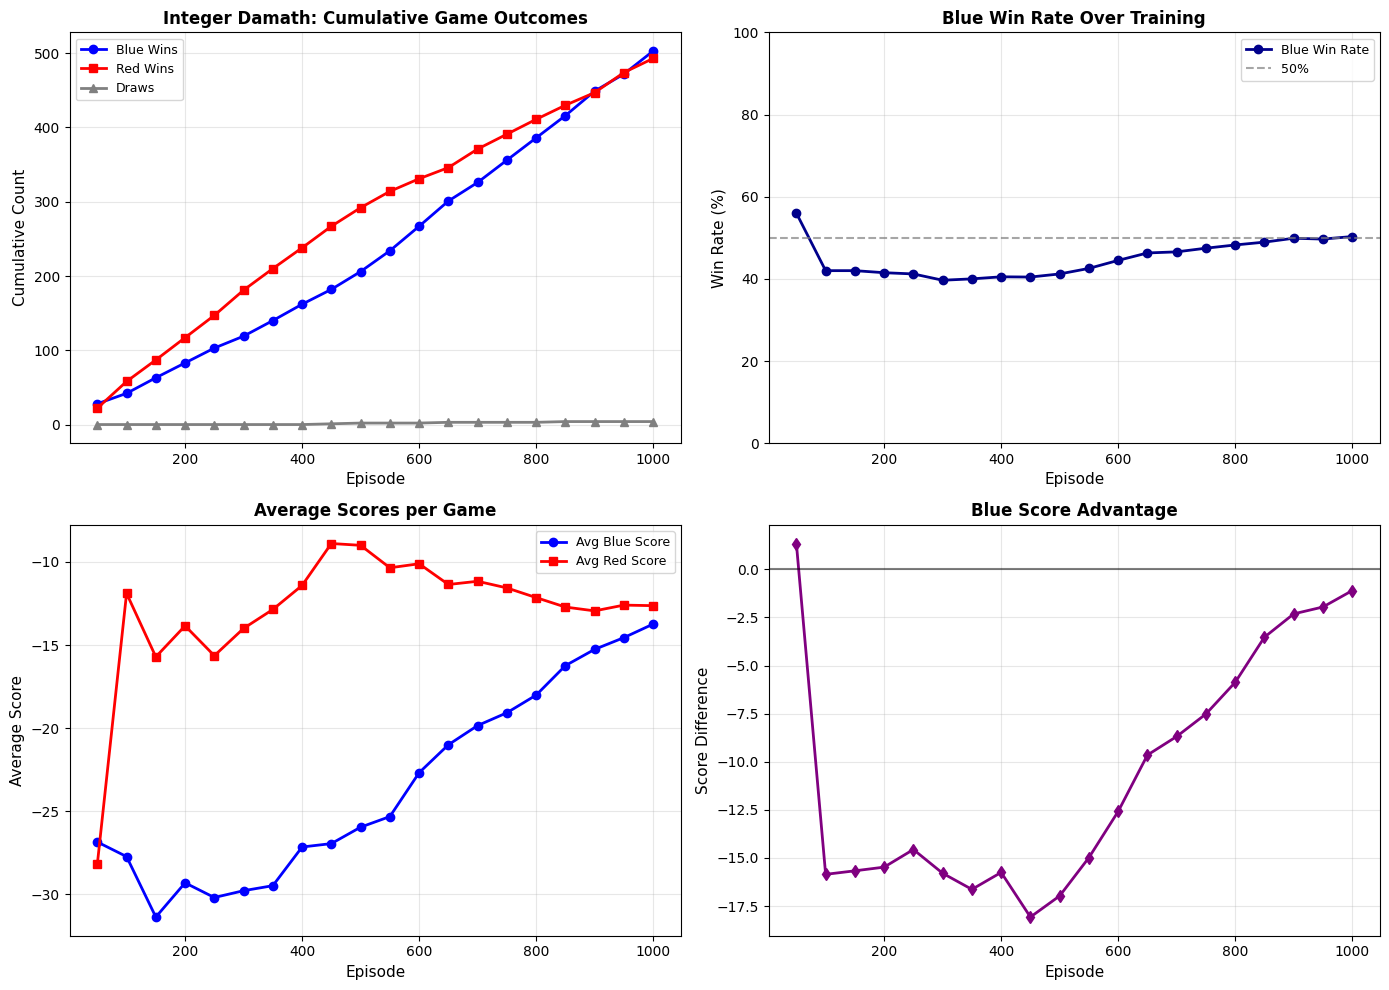

In [52]:
# Create learning curve plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
episodes = df['Episode']

# Plot 1: Cumulative wins
ax1.plot(episodes, df['Blue Wins'], label='Blue Wins', marker='o', linewidth=2, color='blue')
ax1.plot(episodes, df['Red Wins'], label='Red Wins', marker='s', linewidth=2, color='red')
ax1.plot(episodes, df['Draws'], label='Draws', marker='^', linewidth=2, color='gray')
ax1.set_xlabel('Episode', fontsize=11)
ax1.set_ylabel('Cumulative Count', fontsize=11)
ax1.set_title('Integer Damath: Cumulative Game Outcomes', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Win rate
ax2.plot(episodes, df['Blue Win %'], label='Blue Win Rate', 
          marker='o', linewidth=2, color='darkblue')
ax2.axhline(y=50, color='gray', linestyle='--', label='50%', alpha=0.7)
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_ylabel('Win Rate (%)', fontsize=11)
ax2.set_title('Blue Win Rate Over Training', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

# Plot 3: Average scores
ax3.plot(episodes, df['Avg Blue Score'], label='Avg Blue Score', 
          marker='o', linewidth=2, color='blue')
ax3.plot(episodes, df['Avg Red Score'], label='Avg Red Score', 
          marker='s', linewidth=2, color='red')
ax3.set_xlabel('Episode', fontsize=11)
ax3.set_ylabel('Average Score', fontsize=11)
ax3.set_title('Average Scores per Game', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Score difference
score_diff = df['Avg Blue Score'] - df['Avg Red Score']
ax4.plot(episodes, score_diff, linewidth=2, color='purple', marker='d')
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax4.set_xlabel('Episode', fontsize=11)
ax4.set_ylabel('Score Difference', fontsize=11)
ax4.set_title('Blue Score Advantage', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [53]:
print("\nFINAL STATISTICS")
print("="*80)
final = results[-1]
print(f"Total Episodes: {final['Episode']}")
print(f"Blue Wins: {final['Blue Wins']} ({final['Blue Win %']:.2f}%)")
print(f"Red Wins: {final['Red Wins']} ({final['Red Wins']/final['Episode']*100:.2f}%)")
print(f"Draws: {final['Draws']} ({final['Draws']/final['Episode']*100:.2f}%)")
print(f"\nAverage Blue Score: {final['Avg Blue Score']:.2f}")
print(f"Average Red Score: {final['Avg Red Score']:.2f}")
print(f"Score Advantage: {final['Avg Blue Score'] - final['Avg Red Score']:.2f}")
print(f"\nQ-Table Size (Blue): {len(agent1.q_table)} states")
print(f"Q-Table Size (Red): {len(agent2.q_table)} states")
print("="*80)


FINAL STATISTICS
Total Episodes: 1000
Blue Wins: 503 (50.30%)
Red Wins: 493 (49.30%)
Draws: 4 (0.40%)

Average Blue Score: -13.74
Average Red Score: -12.63
Score Advantage: -1.11

Q-Table Size (Blue): 29350 states
Q-Table Size (Red): 29209 states
